<center><span style="font-size:40px;"><b>NUTS vs HMC on GERMAN CREDIT CARD POSTERIOR</b></span></center>

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

In [2]:
#!pip3 install -U ucimlrepo 

---

---

---

# THE CONTEXT

We are working with the Statlog (German Credit Data) dataset, which is a classic classification problem. Each row represents a customer, described by a set of attributes, and the goal is to decide whether that customer is a good or bad credit risk.

The dataset contains 1000 individuals and 20 features. These features are a mix of numerical variables (such as age, credit amount, duration) and categorical variables (encoded as symbols like A11, A34, etc.). The categorical variables represent things like employment status, credit history, housing situation, and so on.

The target variable $y$ is the credit class:
- $y = 1$ means good credit
- $y = 2$ means bad credit

So overall, we are dealing with a supervised binary classification problem, but we will approach it from a Bayesian perspective.

The matrix $X$ contains all the input features. As said, each row is a customer, and each column is an attribute. Many of these attributes are categorical and currently represented as symbolic codes (e.g. A11, A43). These are not directly usable in a regression model, so they will need preprocessing.

The vector $y$ contains the labels. Right now it takes values in $\{1, 2\}$ (but for modeling we will convert it into $\{-1, +1\}$).

Our goal is Bayesian inference. We want to reproduce (and study) a Bayesian logistic regression model, and then compare two sampling algorithms: HMC and NUTS.

Conceptually, we assume that the probability of a customer being "good" (this is the likelihood) depends on a linear combination of the features:
$$
p(y_i = 1 \mid x_i, \alpha, \beta) = \sigma(\alpha + x_i \cdot \beta)
$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the logistic function.

From a Bayesian perspective, we place priors on the parameters:
$$
\alpha \sim \mathcal{N}(0, \sigma^2), \quad \beta_j \sim \mathcal{N}(0, \sigma^2)
$$
with $\sigma^2 = 100$, a very wide (and so weak) prior.

Given the data, we infer their posterior distribution:
$$
p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)
$$

This is the posterior we will sample from using pyMC.

But before defining the model, we need to preprocess the data properly:
* Categorical variables must be converted into numerical form. This is typically done via one-hot encoding, turning each category into binary indicator variables.
* Numerical features should be normalized so that they have comparable scale (zero mean, unit variance). This is important for HMC and NUTS, since their efficiency depends strongly on the geometry of the posterior.
* The target variable $y$ should be transformed into a consistent format (for example $\{-1,1\}$ for Bernoulli likelihood).

Once preprocessing is done, we will:
- define the Bayesian logistic regression model in PyMC
- sample from the posterior using:
  - Hamiltonian Monte Carlo (HMC)
  - No-U-Turn Sampler (NUTS)
- compare their performance using diagnostics such as:
  - effective sample size (ESS)
  - autocorrelation
  - convergence (R-hat)
  - computational cost

The main goal is to understand how HMC and NUTS behave on a real, moderately complex posterior, not anymore just a synthetic Gaussian example.

---

---

---

# DATA UPLOAD (ORIGNAL VERSION)

This version of the dataset has categorical data in some columns.

In [3]:
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 

In [4]:
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features   # X: predictors (features)
y = statlog_german_credit_data.data.targets    # y: labels (credit approval / denial)

In [6]:
# metadata 
# print(statlog_german_credit_data.metadata)     # metadata: general info (source, description, etc.)

In [8]:
# variable information 
display(statlog_german_credit_data.variables)  # variables: schema of dataset (feature names, types)

,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,NaN,Status of existing checking account,NaN,no
1,Attribute2,Feature,Integer,NaN,Duration,months,no
2,Attribute3,Feature,Categorical,NaN,Credit history,NaN,no
3,Attribute4,Feature,Categorical,NaN,Purpose,NaN,no
4,Attribute5,Feature,Integer,NaN,Credit amount,NaN,no
5,Attribute6,Feature,Categorical,NaN,Savings account/bonds,NaN,no
6,Attribute7,Feature,Categorical,Other,Present employment since,NaN,no
7,Attribute8,Feature,Integer,NaN,Installment rate in percentage of disposable i...,NaN,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,NaN,no
9,Attribute10,Feature,Categorical,NaN,Other debtors / guarantors,NaN,no


In [13]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201


In [47]:
# X.dtypes

In [35]:
print(X['Attribute7'].value_counts())

Attribute7
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64


All values appearing in the categorical columns are like `Ai4` with *i* being the column number.

In [52]:
y
# y = 2*y - 3   # to change from {1,2} to {-1, +1}

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: 24, Length: 1000, dtype: int64

---

---

---

# DATA UPLOAD (NUMERICAL VERSION)

This is the version with all numerical columns, and  also the one used in the No U Turn paper.

In [53]:
# URL to the numeric file o the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"

# Il file non ha header e usa spazi bianchi come separatore
df = pd.read_csv(url, sep='\s+', header=None)

# The last column is the target (1 = Good, 2 = Bad)
X = df_numeric.iloc[:, :-1]
y = df_numeric.iloc[:, -1]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12713/3007392204.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None)


In [55]:
X

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,6,4,12,5,5,3,4,1,67,...,1,0,0,1,0,0,1,0,0,1
1,2,48,2,60,1,3,2,2,1,22,...,1,0,0,1,0,0,1,0,0,1
2,4,12,4,21,1,4,3,3,1,49,...,1,0,0,1,0,0,1,0,1,0
3,1,42,2,79,1,4,3,4,2,45,...,1,0,0,0,0,0,0,0,0,1
4,1,24,3,49,1,3,3,4,4,53,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,12,2,17,1,4,2,4,1,31,...,1,0,0,1,0,0,1,0,1,0
996,1,30,2,39,1,3,1,4,2,40,...,1,0,1,1,0,0,1,0,0,0
997,4,12,2,8,1,5,3,4,3,38,...,1,0,0,1,0,0,1,0,0,1
998,1,45,2,18,1,3,3,4,4,23,...,1,0,0,1,0,0,0,0,0,1


In [56]:
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: 24, Length: 1000, dtype: int64

### NORMALIZATION

In [57]:
# Normalization: zero mean and unit variance
X = (X - X.mean())/X.std()
display(X)

# Target change from {1,2} to {-1, +1}
y = 2*y - 3
display(y)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-1.253938,-1.235859,1.343342,-0.733065,1.832252,1.337409,0.449102,1.046463,-1.293076,2.765073,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
1,-0.458797,2.247070,-0.503176,0.965893,-0.699357,-0.317800,-0.963168,-0.765594,-1.293076,-1.190808,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
2,1.131486,-0.738298,1.343342,-0.414510,-0.699357,0.509805,0.449102,0.140434,-1.293076,1.182721,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
3,-1.253938,1.749509,-0.503176,1.638398,-0.699357,0.509805,0.449102,1.046463,-0.340885,0.831087,...,-0.195916,-0.552429,-0.338692,-3.121368,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
4,-1.253938,0.256825,0.420083,0.576549,-0.699357,-0.317800,0.449102,1.046463,1.563498,1.534354,...,-0.195916,1.808378,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.131486,-0.738298,-0.503176,-0.556090,-0.699357,0.509805,-0.963168,1.046463,-1.293076,-0.399632,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
996,-1.253938,0.754386,-0.503176,0.222599,-0.699357,-0.317800,-2.375438,1.046463,-0.340885,0.391544,...,-0.195916,-0.552429,2.949581,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,-1.304224
997,1.131486,-0.738298,-0.503176,-0.874645,-0.699357,1.337409,0.449102,1.046463,0.611307,0.215727,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
998,-1.253938,1.998289,-0.503176,-0.520695,-0.699357,-0.317800,0.449102,1.046463,1.563498,-1.102900,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973


0     -1
1      1
2     -1
3     -1
4      1
      ..
995   -1
996   -1
997   -1
998    1
999   -1
Name: 24, Length: 1000, dtype: int64

### MODEL

The target distribution is $p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)$, so:

$$
p(\alpha, \beta \mid X, y) \propto
\exp\left(
-\sum_{i}\log\!\left(1+\exp\!\left\{-y_i\left(\alpha + x_i \cdot \beta\right)\right\}\right)
-\frac{\alpha^2}{2\sigma^2}
-\frac{1}{2\sigma^2}\,\beta \cdot \beta
\right)
$$



In [60]:
# "α and each element of β are given weak zero-mean normal priors with variance σ^2 = 100"
prior_mean = 0
prior_var = 100

TARGET_ACCEPT = 0.9
CHAINS = 4

In [62]:
with pm.Model() as model:
    X_data = pm.Data( "X", X )
    y_data = pm.Data( "y", y )

    # Priors
    alpha = pm.Normal( "alpha", mu=0.0, sigma=np.sqrt(prior_var) )
    beta  = pm.Normal( "beta",  mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1] )

    # eta_i = alpha + x_i * beta
    eta = alpha + pt.dot( X_data, beta )

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # log1p is log(1+...) and is more numerically stable
    loglike = -pt.sum( pt.log1p( pt.exp( -y_data * eta ) ) ) # maybe better: loglike = -pt.sum(pt.nnet.softplus(-y_data * eta))
    pm.Potential("likelihood", loglike)

    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=CHAINS,
        target_accept=TARGET_ACCEPT,
        random_seed=2026,
        progressbar = True,
        nuts_sampler = "pymc"
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [63]:
summary_nuts = az.summary(idata, var_names=["alpha", "beta"], round_to=3)
display(summary_nuts)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.218,0.093,-1.394,-1.044,0.001,0.001,6172.038,3199.686,1.001
beta[0],-0.746,0.092,-0.911,-0.570,0.001,0.001,7107.801,3353.072,1.002
beta[1],0.426,0.104,0.216,0.611,0.001,0.002,6245.826,3446.752,1.001
beta[2],-0.420,0.095,-0.598,-0.242,0.001,0.001,4895.050,3164.292,1.001
beta[3],0.126,0.108,-0.071,0.327,0.001,0.002,5884.934,3114.790,1.001
beta[4],-0.370,0.095,-0.555,-0.198,0.001,0.002,7064.624,2950.805,1.000
beta[5],-0.181,0.092,-0.348,-0.001,0.001,0.001,6412.520,3455.023,1.000
beta[6],-0.154,0.084,-0.311,-0.002,0.001,0.002,7404.699,2853.551,1.000
beta[7],0.013,0.091,-0.150,0.191,0.001,0.001,7116.921,2983.005,1.002
beta[8],0.183,0.104,-0.009,0.383,0.001,0.002,5999.539,3048.681,1.002


Number of parameters with R_hat > 1.05: 0


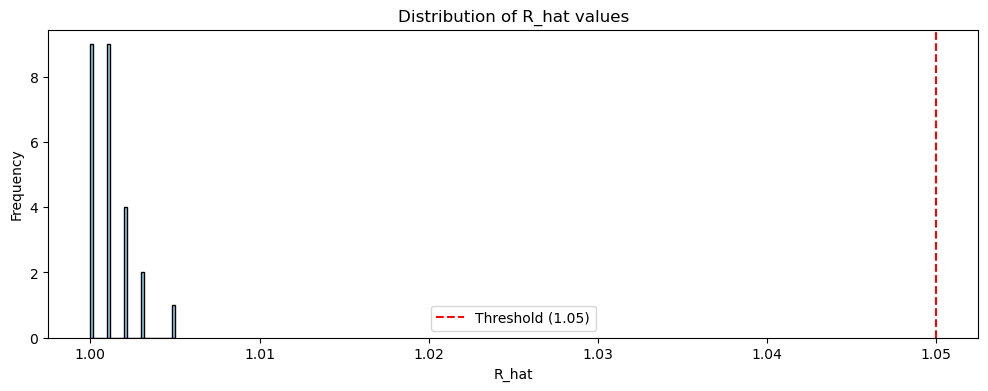

Number of parameters with ESS_bulk < 400: 0
Number of divergences: 0


In [64]:
# 1) Count how many rows exceed R_hat > 1.05
rhat_exceed = (summary_nuts['r_hat'] > 1.05).sum()
print(f"Number of parameters with R_hat > 1.05: {rhat_exceed}")

# 2) Plot the distribution of R_hat
plt.figure(figsize=(12, 4))
plt.hist(summary_nuts['r_hat'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(1.05, color='red', linestyle='--', label='Threshold (1.05)')
plt.title('Distribution of R_hat values')
plt.xlabel('R_hat')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 3) Check ESS (Effective Sample Size)
# Generally, we look at 'ess_bulk' or 'ess_tail'
# A common rule of thumb is ESS > 100 * number of chains (e.g., 400)
ess_threshold = 400
low_ess = (summary_nuts['ess_bulk'] < ess_threshold).sum()
print(f"Number of parameters with ESS_bulk < {ess_threshold}: {low_ess}")

# Optional: Display parameters that failed the checks
if rhat_exceed > 0:
    print("\nParameters with R_hat > 1.05:")
    print(summary_nuts[summary_nuts['r_hat'] > 1.05])

print("Number of divergences:", int(idata.sample_stats["diverging"].sum()))

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta\n0', ylabel='beta\n7'>,
        <Axes: xlabel='beta\n1'>, <Axes: xlabel='beta\n2'>,
        <Axes: xlabel='beta\n3'>, <Axes: xlabel='beta\n4'>,
        <Axes: xlabel='beta\n5'>, <Ax

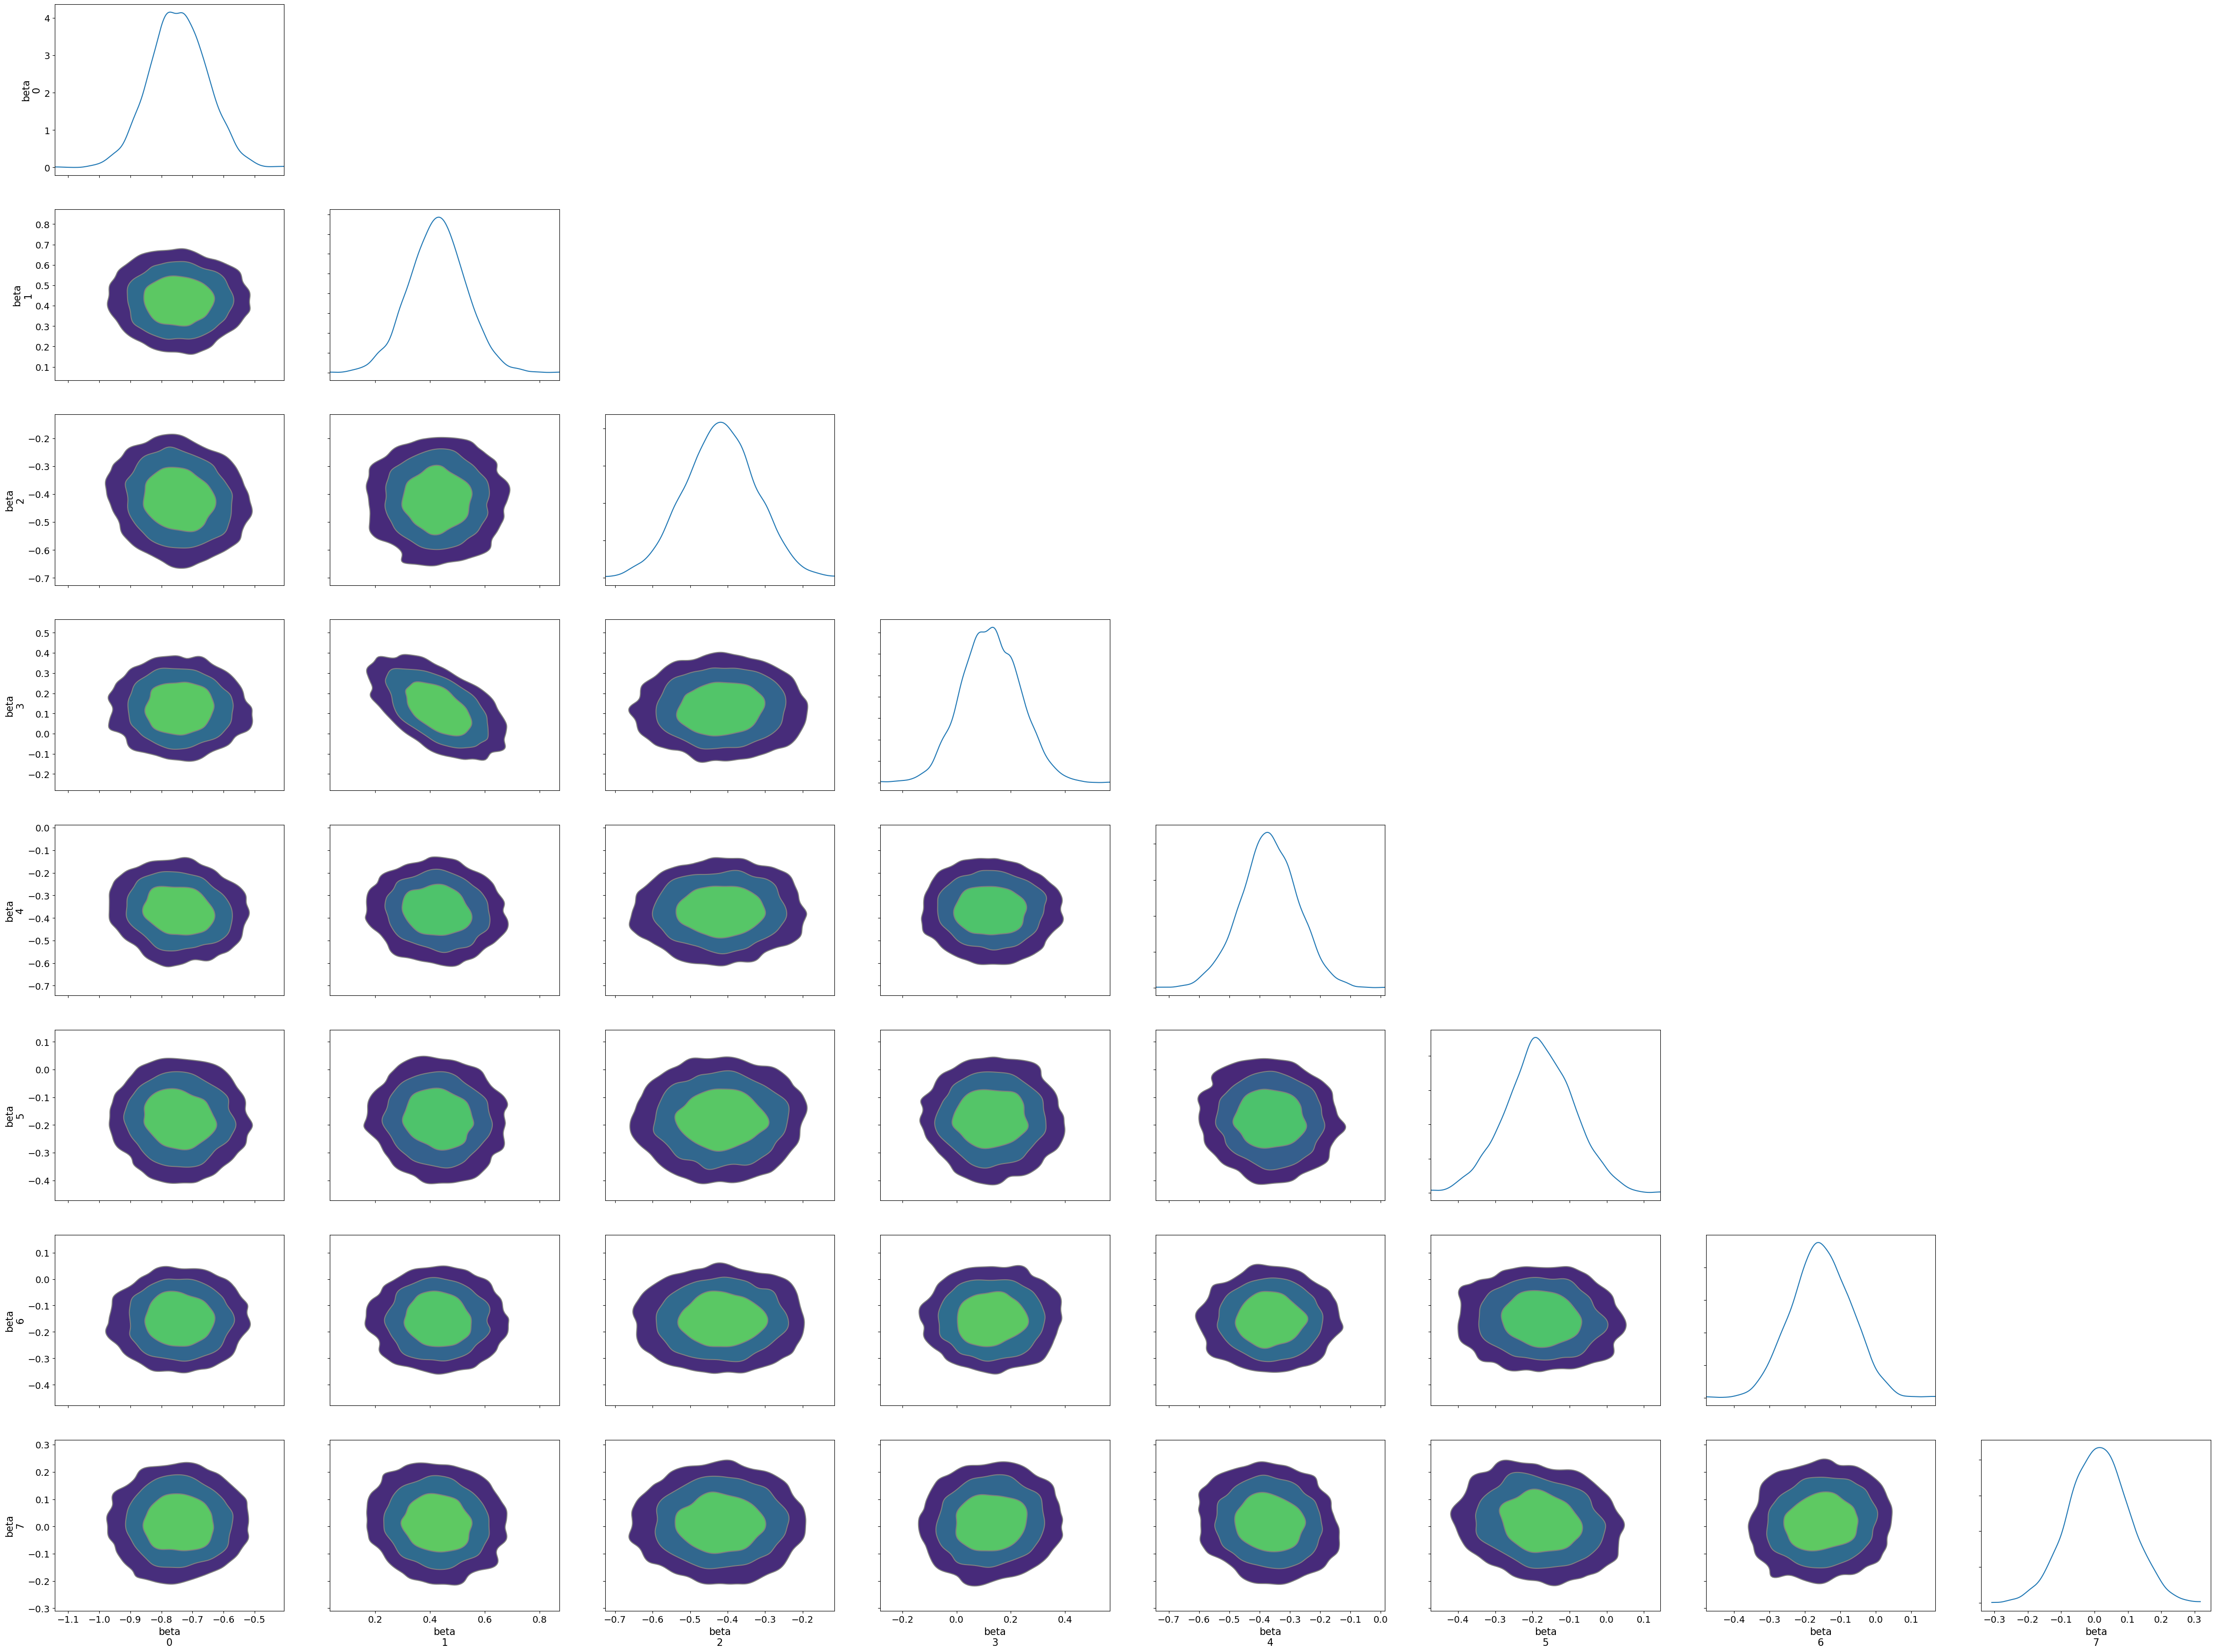

In [65]:
az.plot_pair(idata, var_names=["beta"], kind="kde", marginals=True)

In [66]:
idata.sample_stats["acceptance_rate"]

<xarray.DataArray 'acceptance_rate' (chain: 4, draw: 1000)> Size: 32kB
array([[0.93798302, 0.98216588, 0.92194481, ..., 0.87687798, 0.98111191,
        0.99116195],
       [0.85328748, 0.95744698, 0.95566457, ..., 0.65391955, 0.9606991 ,
        0.98615957],
       [0.96941111, 0.99850036, 0.99861264, ..., 0.9152949 , 0.95226829,
        0.81432687],
       [1.        , 0.76483135, 0.94541804, ..., 0.98856657, 0.91869866,
        0.91205292]], shape=(4, 1000))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

# (READ TILL HERE)

min/max h: 0.8964 / 0.9063
chain 0: h=0.9063, diff=+0.0063, mcse=0.0019, CI95(diff)=[0.0025 : 0.0101] Zero inside: False
chain 1: h=0.9023, diff=+0.0023, mcse=0.0024, CI95(diff)=[-0.0023 : 0.0069] Zero inside: True
chain 2: h=0.9005, diff=+0.0005, mcse=0.0022, CI95(diff)=[-0.0037 : 0.0047] Zero inside: True
chain 3: h=0.8964, diff=-0.0036, mcse=0.0025, CI95(diff)=[-0.0084 : 0.0013] Zero inside: True
pooled:  h = 0.9014, diff = 0.0014, CI95(diff)=[-0.0009 : 0.0038] Zero inside: True


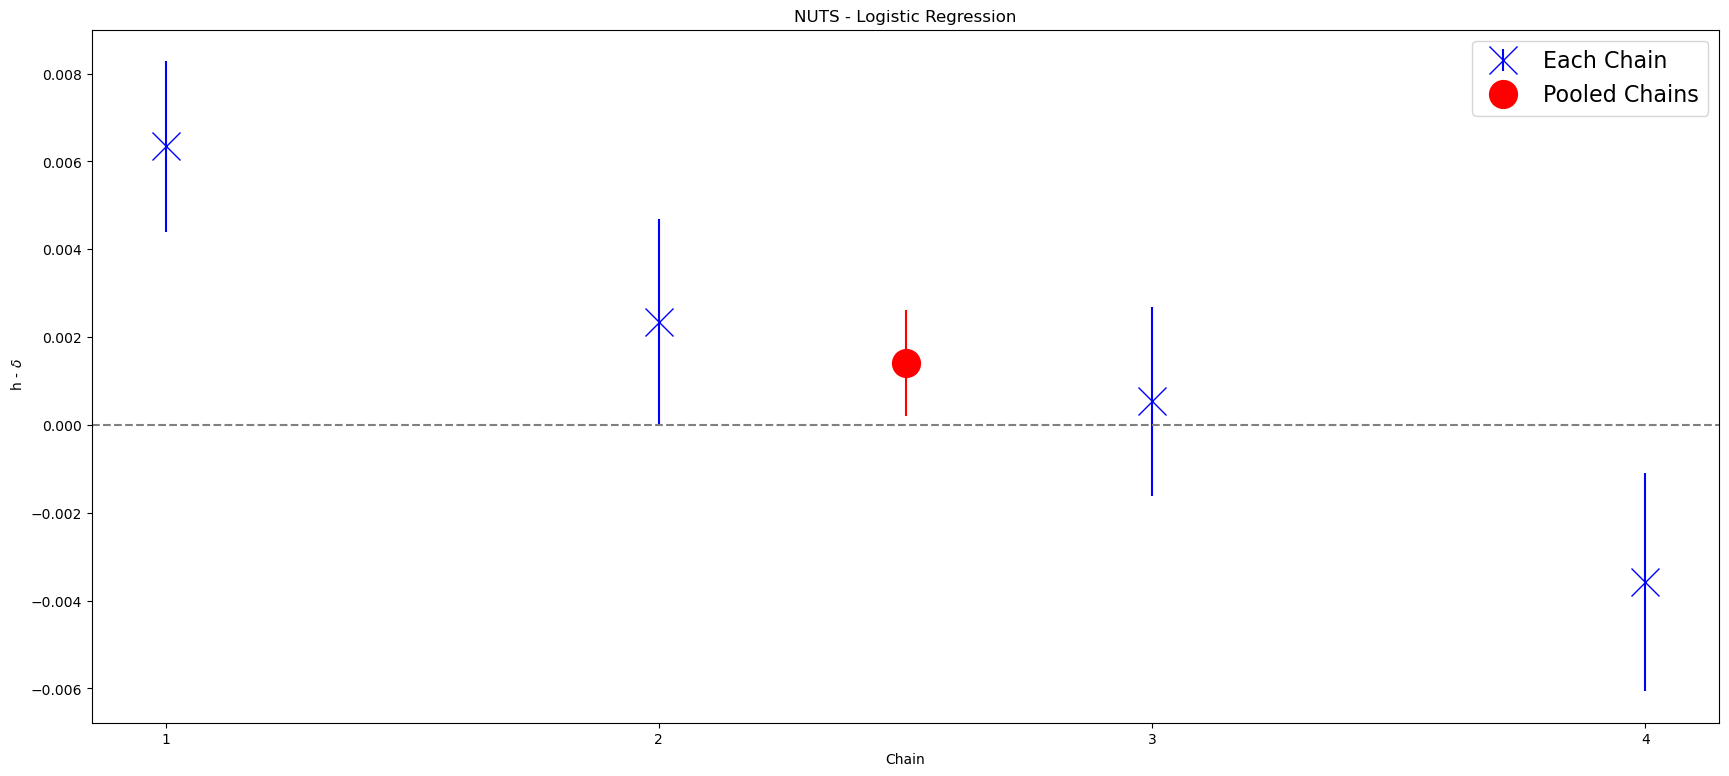

In [12]:
# Error on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    x = np.asarray(x, dtype=float).ravel()
    n = x.size
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size
    if m < min_batches:
        batch_size = max(1, n // min_batches)
        m = n // batch_size
    if m < 2:
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")
    n_used = m * batch_size
    x_used = x[:n_used]
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)
    mcse = batch_means.std(ddof=1) / np.sqrt(m)
    return mcse

acceptance = idata.sample_stats["acceptance_rate"].to_numpy()
h_chain = acceptance.mean(axis=1)
diff_chain = h_chain - TARGET_ACCEPT
    
print(f"min/max h: {h_chain.min():.4f} / {h_chain.max():.4f}")

mcse = np.zeros(CHAINS)

z = 1.96  # ~95% normal quantile
for c in range(CHAINS):
    h = acceptance[c].mean()
    diff = h - TARGET_ACCEPT
    mcse[c] = mcse_batch_means(acceptance[c])
    ci95 = (diff - z*mcse[c], diff + z*mcse[c])
    print(f"chain {c}: h={h:.4f}, diff={diff:+.4f}, mcse={mcse[c]:.4f}, CI95(diff)=[{ci95[0]:.4f} : {ci95[1]:.4f}] Zero inside: {ci95[0]*ci95[1]<0}")

h_pooled = acceptance.mean()
diff_pooled = h_pooled - TARGET_ACCEPT
mcse_pooled = mcse_batch_means(acceptance.reshape(-1))  # concatenate
ci95_pooled = (diff_pooled - 1.96*mcse_pooled, diff_pooled + 1.96*mcse_pooled)
print("pooled:", f" h = {h_pooled:.4f}, diff = {diff_pooled:.4f}, CI95(diff)=[{ci95_pooled[0]:.4f} : {ci95_pooled[1]:.4f}] Zero inside: {ci95_pooled[0]*ci95_pooled[1]<0}")

# plot with errorbars
fig, ax = plt.subplots(figsize=(21,9))
plt.errorbar(x = np.arange(1, CHAINS+1, 1), y = diff_chain, yerr = mcse, ls="", fmt="x", ms=20, label="Each Chain", color="blue" )
plt.errorbar(x = (CHAINS+1)/2, y = diff_pooled, yerr = mcse_pooled, ls="", fmt="o", ms=20, label="Pooled Chains", color = "red" )
plt.xlabel("Chain")
plt.ylabel(r" h - $\delta$")
plt.title("NUTS - Logistic Regression")
plt.xticks(np.arange(1, CHAINS+1, 1))
plt.legend(loc="upper right", fontsize=16)
plt.axhline(y=0.0, ls="--", color="gray")
plt.show()

In [13]:
# In function of the target acceptance:
prior_mean = 0
prior_var = 100

CHAINS = 4
accept_rate_list = np.arange(0.20, 0.99, 0.02)
all_diffs = np.zeros(shape=(len(accept_rate_list), CHAINS))
all_mcse = np.zeros_like(all_diffs)

ESS_GRAD_EV_ALPHA = []
ESS_GRAD_EV_BETA = []
ESS_GRAD_EV_SCALAR = []

with pm.Model() as model:
    X_data = pm.Data( "X", X )
    y_data = pm.Data( "y", y )

    # Priors
    alpha = pm.Normal( "alpha", mu=0.0, sigma=np.sqrt(prior_var) )
    beta  = pm.Normal( "beta",  mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1] )

    # eta_i = alpha + x_i * beta
    eta = alpha + pt.dot( X_data, beta )

    # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
    # log1p is log(1+...) and is more numerically stable
    loglike = -pt.sum( pt.log1p( pt.exp( -y_data * eta ) ) )

    pm.Potential("likelihood", loglike)

    for i, target_accept in enumerate(accept_rate_list):
        print(f"Iteration {i+1} of {len(accept_rate_list)}")
        idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=CHAINS,
        target_accept=target_accept,
        random_seed=2026+i,
        progressbar = False,
        quiet = True,
        nuts_sampler = "pymc",
        
        )

        acceptance = idata.sample_stats["acceptance_rate"].to_numpy()
        h_chain = acceptance.mean(axis=1)
        diff_chain = h_chain - target_accept
        mcse = np.zeros(CHAINS)
        for c in range(CHAINS):
            mcse[c] = mcse_batch_means(acceptance[c])
        all_diffs[i] = diff_chain
        all_mcse[i]  = mcse

        # Trying to replicate the ESS/gradient_evaluation graphs

        # First, I get the number of steps (POST WARM UP) for each chain
        n_steps = idata.sample_stats["n_steps"].to_numpy()   # shape (chains, draws)
        
        # 1 step = 1 Leapfrog = 1 gradient
        total_grad_evals = n_steps.sum(axis=1)
        
        # number of chains
        chains = idata.posterior.sizes["chain"]
        
        # alpha is a scalar, so 1 value per chain
        ess_bulk_per_chain_alpha = np.zeros(shape=(chains, 1))
        
        # beta is a vector, so 24 values per chain
        ess_bulk_per_chain_beta = np.zeros(shape=(chains, 24))
        
        
        for c in range(chains):
            id_c_post = idata.posterior.isel(chain=[c])   # keep chain
            ess_bulk_c = az.ess(id_c_post, method="bulk")
            ess_bulk_per_chain_alpha[c] = ess_bulk_c["alpha"]
            ess_bulk_per_chain_beta[c] = ess_bulk_c["beta"]
        
        ess_per_grad_per_chain_alpha = ess_bulk_per_chain_alpha.reshape(chains,) / n_steps.sum(axis=1)
        
        ess_per_grad_per_chain_beta = np.zeros(shape=(chains, 24))
        for c in range(chains):
            ess_per_grad_per_chain_beta[c] = ess_bulk_per_chain_beta[c] / n_steps.sum(axis=1)[c]
        
        # Mean for each variable averaging over all chains
        mean_ess_grad_alpha = np.mean(ess_per_grad_per_chain_alpha)
        mean_ess_grad_beta = np.mean(ess_per_grad_per_chain_beta, axis=0)
        
        # Singular value across all chains and all variables:
        ESS_PER_GRAD = np.mean( [mean_ess_grad_alpha, mean_ess_grad_beta.mean()] )

        ESS_GRAD_EV_ALPHA.append(ess_per_grad_per_chain_alpha)
        ESS_GRAD_EV_BETA.append(ess_per_grad_per_chain_beta)
        ESS_GRAD_EV_SCALAR.append(ESS_PER_GRAD)

Iteration 1 of 40
Iteration 2 of 40
Iteration 3 of 40
Iteration 4 of 40
Iteration 5 of 40
Iteration 6 of 40
Iteration 7 of 40
Iteration 8 of 40
Iteration 9 of 40
Iteration 10 of 40
Iteration 11 of 40
Iteration 12 of 40
Iteration 13 of 40
Iteration 14 of 40
Iteration 15 of 40
Iteration 16 of 40
Iteration 17 of 40
Iteration 18 of 40
Iteration 19 of 40
Iteration 20 of 40
Iteration 21 of 40
Iteration 22 of 40
Iteration 23 of 40
Iteration 24 of 40
Iteration 25 of 40
Iteration 26 of 40
Iteration 27 of 40
Iteration 28 of 40
Iteration 29 of 40
Iteration 30 of 40
Iteration 31 of 40
Iteration 32 of 40
Iteration 33 of 40
Iteration 34 of 40
Iteration 35 of 40
Iteration 36 of 40
Iteration 37 of 40
Iteration 38 of 40
Iteration 39 of 40
Iteration 40 of 40


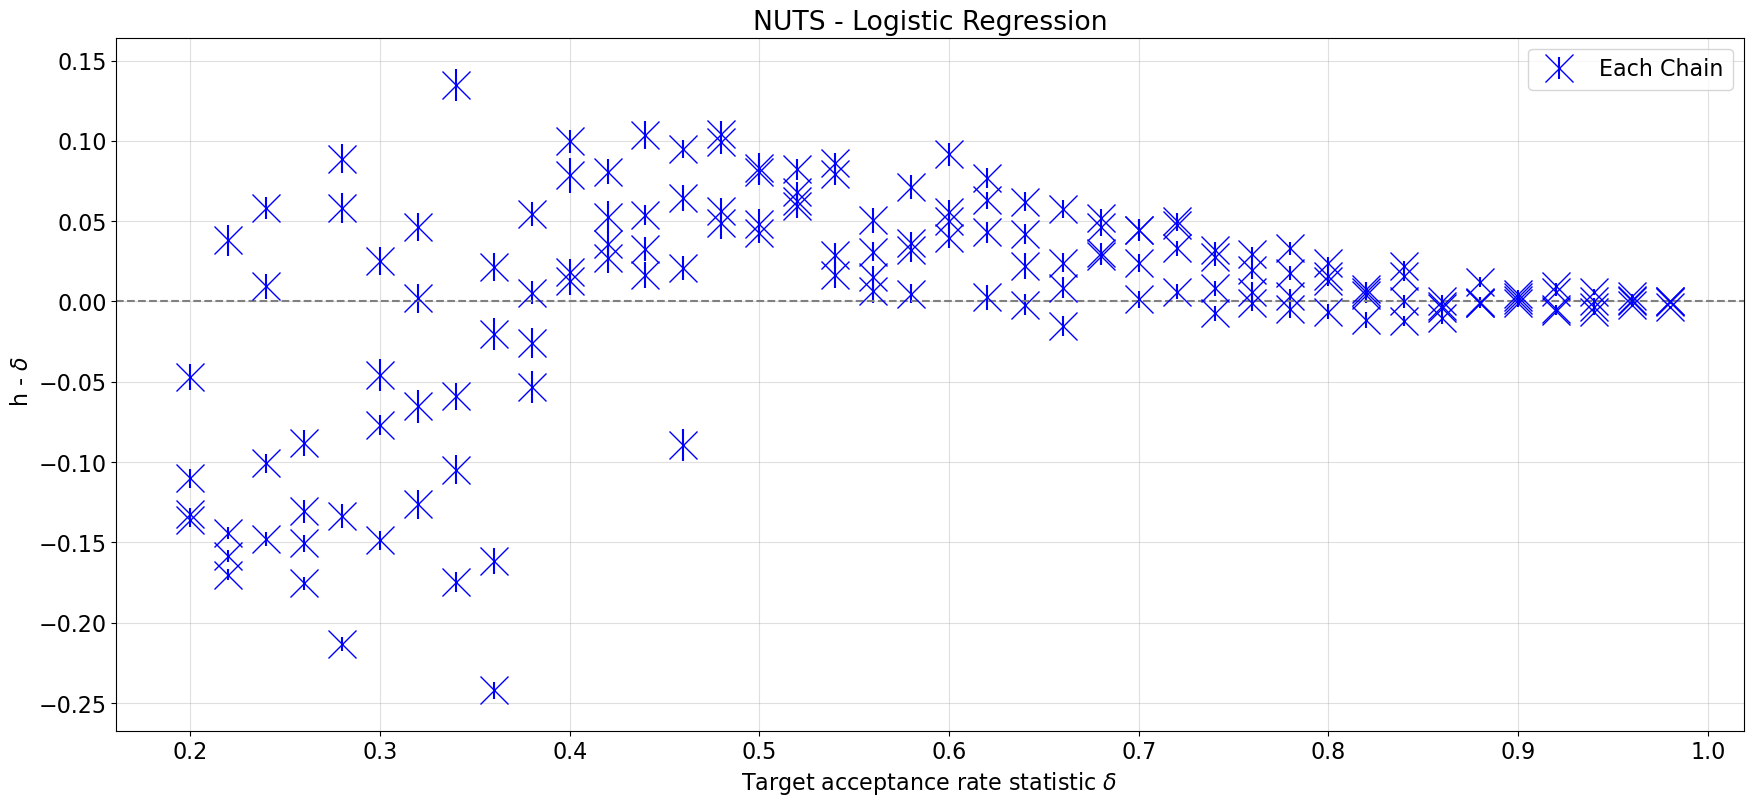

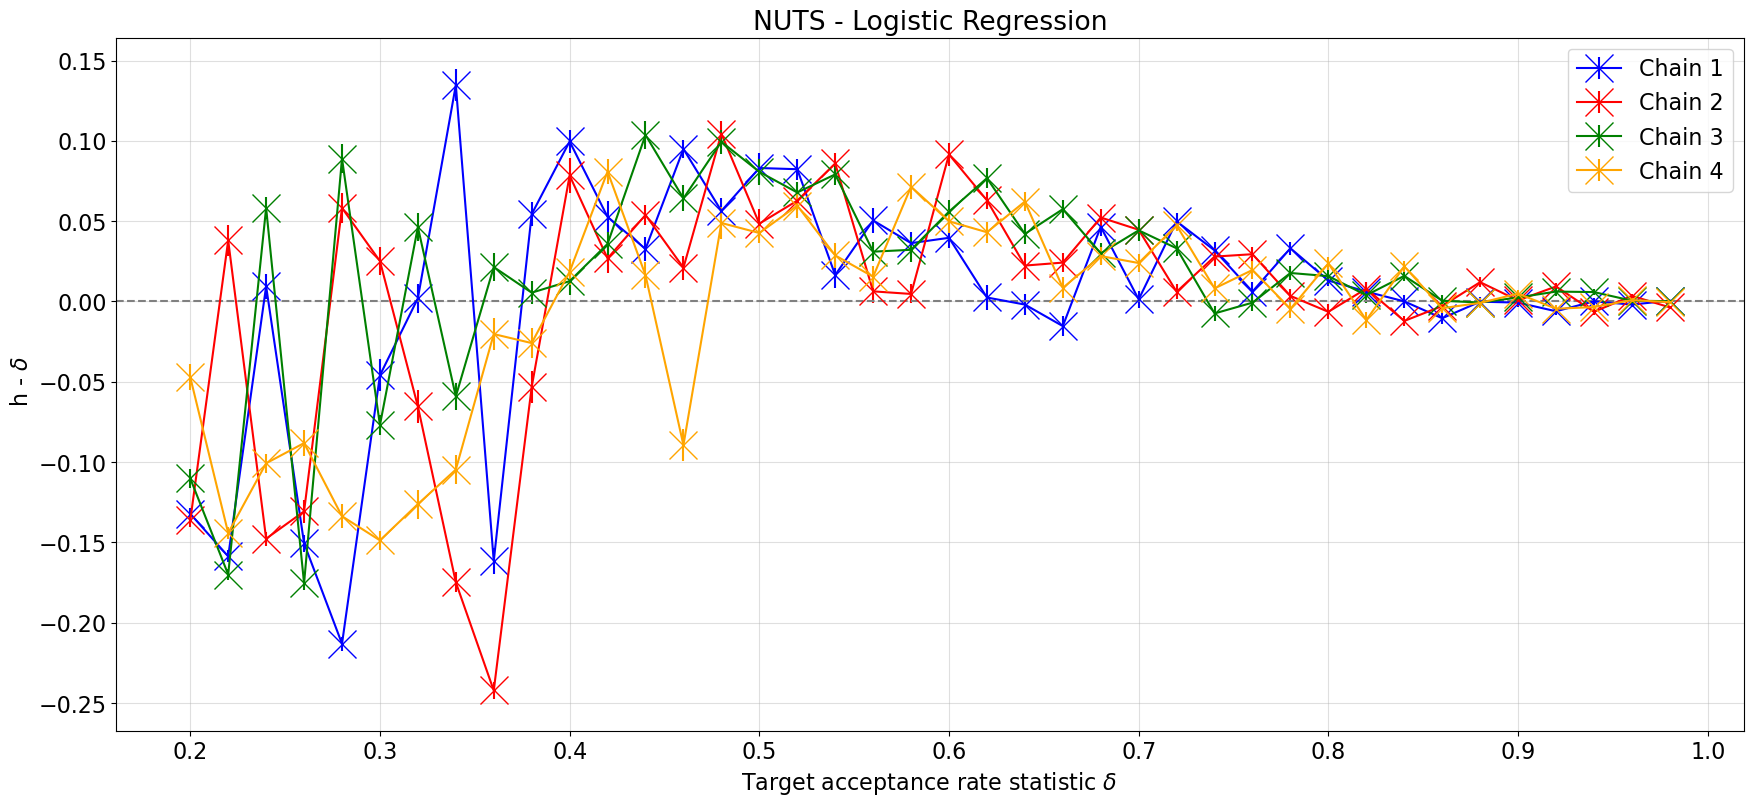

In [14]:
plt.rcParams.update({'font.size': 16})

repeated_X = [ val for val in accept_rate_list for _ in range(CHAINS) ]
repeated_X

# plot with errorbars
fig, ax = plt.subplots(figsize=(21,9))
plt.errorbar(x = repeated_X, y = all_diffs.flatten(), yerr = all_mcse.flatten(), ls="", fmt="x", ms=20, label="Each Chain", color="blue" )
plt.xlabel(r"Target acceptance rate statistic $\delta$ ")
plt.ylabel(r" h - $\delta$")
plt.title("NUTS - Logistic Regression")
plt.legend(loc="upper right", fontsize=16)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

# or different color for each chain
colors = ["blue", "red", "green", "orange"]
fig, ax = plt.subplots(figsize=(21,9))
for c in range(CHAINS):
    ax.errorbar(x = accept_rate_list, y = all_diffs[:,c], yerr = all_mcse[:,c], ls="-", fmt="x", ms=20, label=f"Chain {c+1}", color=colors[c]
               )
plt.xlabel(r"Target acceptance rate statistic $\delta$ ")
plt.ylabel(r" h - $\delta$")
plt.title("NUTS - Logistic Regression")
plt.legend(loc="upper right", fontsize=16)
plt.axhline(y=0.0, ls="--", color="gray")
plt.grid(alpha=0.4)
plt.show()

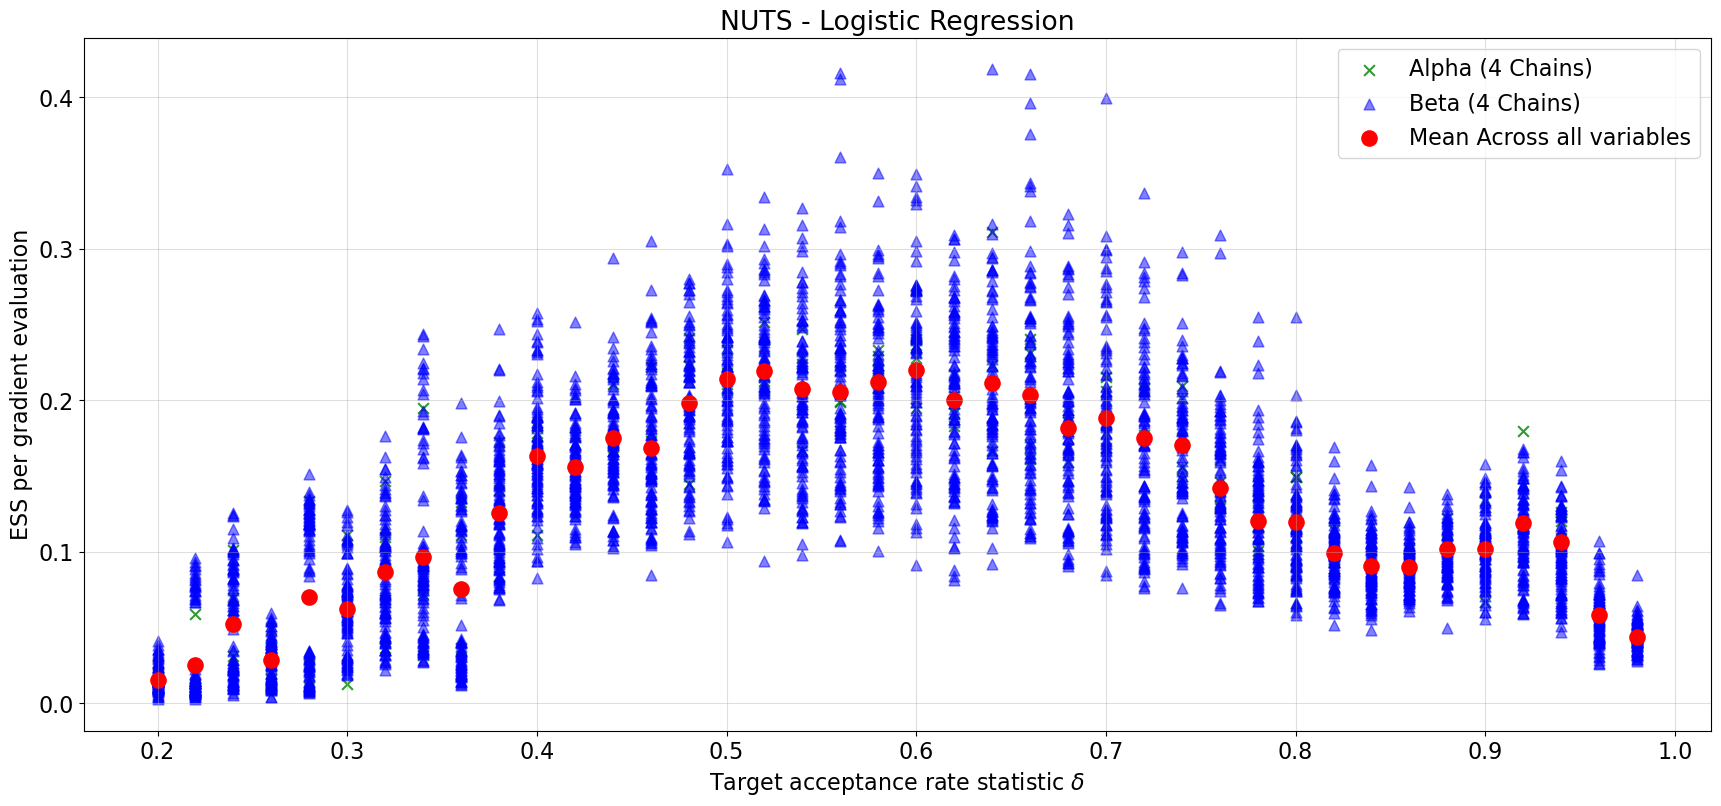

In [15]:
repeated_X = [ val for val in accept_rate_list for _ in range(CHAINS) ]

# plot with errorbars
fig, ax = plt.subplots(figsize=(21,9))
plt.scatter(x = repeated_X, y = ESS_GRAD_EV_ALPHA, marker="x", label="Alpha (4 Chains)", color="green", alpha = 0.8, s = 60)
repeated_X = [ val for val in accept_rate_list for _ in range(CHAINS*24) ]
plt.scatter(x = repeated_X, y = ESS_GRAD_EV_BETA, marker="^", label="Beta (4 Chains)", color="blue", alpha = 0.5 , s = 60)
plt.scatter(x = accept_rate_list, y = ESS_GRAD_EV_SCALAR, marker="o", label="Mean Across all variables", color="red", s = 120)

plt.xlabel(r"Target acceptance rate statistic $\delta$ ")
plt.ylabel("ESS per gradient evaluation")
plt.title("NUTS - Logistic Regression")
plt.legend(loc="upper right", fontsize=16)
plt.grid(alpha=0.4)
plt.show()